# Bayesian quadrature with kernel mean embeddings

This notebook shows how to use kernel mean embeddings for Bayesian quadrature (BQ). Note that `kernel_embedding_dictionary` does not implement any method, so you still need to implement your own BQ, but you don't have to do the integrals :)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Recap: BQ

Assume we want to compute the integral of a function
    $$ F = \int_\Omega f(x)\ \mathrm{d} P(x)$$

In Bayesian quadrature, you model the true function $f$ with a Gaussian process surrogate $\tilde{f} \sim \mathcal{GP} (m, k)$ with mean function $m$$ and kernel $k$. We assume the prior mean $m$ to be zero.

After (noise-free) observations $f(X)$ at locations $X = [x_1, ..., x_N]$, the posterior has mean and covariance
    $$ m_N (x) = k(x, X) [K(X, X)]^{-1} f(X)$$
    $$ k_N (x, x') = k(x, x') - k(x, X) [K(X, X)]^{-1} k(X, x)$$

Due to linearity, the integral is Gaussian
    $$ \tilde{F}_X \sim \mathcal{N} (M_N, V_N)$$
where mean and variance
    $$M_N = k_P(X)^T [K(X, X)]^{-1} f(X)$$
    $$V_N = k_{PP} - k_P(X)^T [K(X, X)]^{-1} k_P(X)$$
require computing the kernel mean
    $$k_P(X) = \int_\Omega k(X, x)\ \mathrm{d} P(x)$$
and the integrated kernel mean
    $$k_{PP} = \iint_\Omega k(x, x')\ \mathrm{d} P(x)\mathrm{d} P(x')$$


#### Note on integrated kernel means
The implementation of integrated kernel means is currently work in progress, so we'll cheat here and compute them numerically.

In [2]:
# 2-dimensional test function
ndim = 2

In [3]:
# Let's define a test function
def adjiman_function(x: np.ndarray) -> np.ndarray:
    """Define the Adjiman function."""
    x1, x2 = x[:, 0], x[:, 1]
    term1 = np.cos(x1) * np.sin(x2)
    term2 = - x1 / (x2**2 + 1)
    return term1 + term2

def adjiman_function_x_y(x: float, y: float) -> float:
    """Adjiman function as a function of two floats. Needed for dblquad"""
    x_arr = np.asarray([x, y]).reshape(1, -1)
    return adjiman_function(x_arr)[0]

In [4]:
# Let's define where to evaluate
N = 50
X = np.random.rand(N, ndim)*4 - 2
fX = adjiman_function(X)

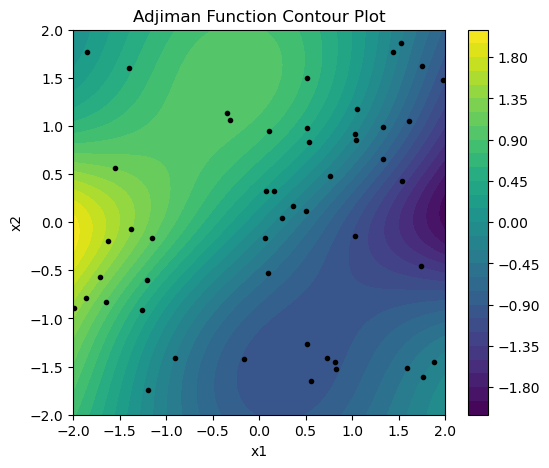

In [5]:
# Generate a grid of points
x1 = np.linspace(-2, 2, 100)
x2 = np.linspace(-2, 2, 100)
X1, X2 = np.meshgrid(x1, x2)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

# Evaluate the function on the grid
Z = adjiman_function(X_grid).reshape(X1.shape)

# Plot contour
plt.figure(figsize=(6, 5))
contour = plt.contourf(X1, X2, Z, levels=30, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c='k', marker='.')
plt.colorbar(contour)
plt.title("Adjiman Function Contour Plot")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

### Ground truth

Due to symmetry, the true integral of the function on the given domain is 0.

### Bayesian quadrature

Let's use an exponential quadratic kernel, and the Lebesgue measure on $[-2, 2]^2$.

In [8]:
from kernel_embedding_dictionary.kernels import ExpQuadKernel
from kernel_embedding_dictionary.measures import LebesgueMeasure
from kernel_embedding_dictionary.embeddings import KernelEmbedding

kernel_config = {
    "ndim": 2,
    "lengthscales": [0.4, 0.4]
}

measure_config = {
    "ndim": 2,
    "bounds": [(-2, 2), (-2, 2)],
    "normalize": True,
}

# Let's define kernel and measure separately, because we want to use the kernel

k = ExpQuadKernel(kernel_config)
m = LebesgueMeasure(measure_config)

ke = KernelEmbedding(k, m)

print(ke)


Kernel embedding for

exponentiated quadratic kernel 
dimensionality: 2 
lengthscales: [0.4, 0.4]

and

Lebesgue measure 
dimensionality: 2 
normalized: True
density: 0.0625
bounds: [(-2, 2), (-2, 2)]


Define random points to evaluate the function

In [9]:
from scipy.integrate import dblquad

def integral_mean(kernel, kernel_embedding, X, fX):
    """compute the integrated mean of the Gaussian process."""
    kXX = kernel.evaluate(X, X)
    kmeanX = kernel_embedding.mean(X)
    return kmeanX @ np.linalg.solve(kXX + 1.e-4*np.diag(np.ones(shape=(X.shape[0],))), fX)

def integral_variance(kernel, measure, kernel_embedding, X):
    """Note the variance is independent of observed function values."""
    def scalar_kmean(x, y):
        x_arr = np.asarray([x, y])[None, :]
        return kernel_embedding.mean(x_arr)
    
    # Cheating here:
    integrated_kmean, _ = dblquad(scalar_kmean, 
                                  measure.bounds[0][0], 
                                  measure.bounds[0][1], 
                                  measure.bounds[1][0], 
                                  measure.bounds[1][1],
                                  )
    integrated_kmean = measure.density*integrated_kmean

    kXX = kernel.evaluate(X, X)
    kmeanX = kernel_embedding.mean(X)
    variance_reduction = kmeanX @ np.linalg.solve(kXX + 1.e-4*np.diag(np.ones(shape=(X.shape[0],))), kmeanX.T)
    return integrated_kmean - variance_reduction


In [10]:
# Results

i_mean = integral_mean(k, ke, X, fX)
i_var = integral_variance(k, m, ke, X)

Plot the BQ result

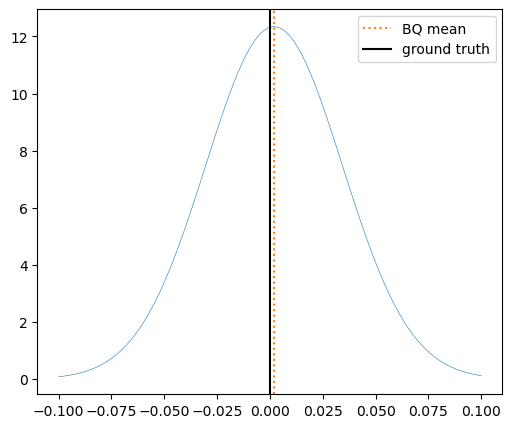

In [11]:
from scipy.stats import norm

x = np.linspace(-0.1, 0.1, 100)
gauss_x = norm(i_mean, i_var).pdf(x)

plt.figure(figsize=(6, 5))
plt.plot(x, gauss_x, lw=0.4)
plt.axvline(i_mean, c="C1", ls=":", label="BQ mean")
plt.axvline(0., c="k", label="ground truth")
plt.legend()
plt.show()